## Supervised Learning: Final Pipeline

This section presents the final supervised learning pipeline for predicting driver pay.
The pipeline integrates data loading, preprocessing, feature engineering, model training,
hyperparameter tuning, and final evaluation into a single reproducible workflow.

The objective is to identify the best-performing model and evaluate its generalization
performance on unseen test data.

# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.linear_model import LinearRegression, Lasso
import xgboost as xgb
from google.colab import drive
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import PartialDependenceDisplay

# 2. Configuration and Data Loading

In [2]:

drive.mount('/content/drive')   # Comment out if data is not on google drive

DATA_PATH = "/content/drive/MyDrive/COMP 333 - Project/processed_data/tripdata_clean_full.parquet"   # change this to a relative path
OUTPUT_DIR = "/content/drive/MyDrive/COMP 333 - Project/processed_data"

TARGET_COL = "driver_pay"

BASE_FEATURES = [
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "tips",
    "pickup_datetime"
]

RANDOM_STATE = 42

TUNE_SAMPLE_SIZE = 50000

# Final features after engineering
FINAL_FEATURES = [
    "trip_miles", "trip_time",
    "base_passenger_fare", "tips",
    "pickup_hour", "pickup_dayofweek",
    "avg_speed", "trip_miles_sq"
]

cols = BASE_FEATURES + [TARGET_COL]

df = pd.read_parquet(DATA_PATH, columns=cols)

# Error handling for missing columns
missing_cols = set(cols) - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

Mounted at /content/drive


# 3. Utility functions


In [29]:
# Reduce memory usage by downcasting numeric columns
def optimize_dtypes(df):
    df = df.copy()

    float_cols = df.select_dtypes(include=["float64"]).columns
    int_cols = df.select_dtypes(include=["int64"]).columns

    df[float_cols] = df[float_cols].astype("float32")
    df[int_cols] = df[int_cols].astype("int32")

    return df

# Apply feature engineering for supervised learning
def engineer_features(df):
    df = df.copy()

    # Convert pickup_datetime safely
    df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")

    # Time-based features
    df["pickup_hour"] = df["pickup_datetime"].dt.hour.astype("float32")
    df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek.astype("float32")

    # Trip time in hours
    df["trip_hours"] = df["trip_time"] / 3600.0

    # Avoid division by zero
    df["avg_speed"] = df["trip_miles"] / (df["trip_hours"] + 1e-6)

    # Polynomial feature
    df["trip_miles_sq"] = df["trip_miles"] ** 2

    return df

#  Select input features (X) and target (y) from the dataframe
def prepare_features_target(df, feature_cols, target_col):
    missing_features = [col for col in feature_cols if col not in df.columns]
    if missing_features:
        raise ValueError(f"Missing feature columns: {missing_features}")

    if target_col not in df.columns:
        raise ValueError(f"Missing target column: {target_col}")

    X = df[feature_cols].copy()
    y = df[target_col].copy()

    return X, y

def split_data(X, y, random_state=42):
    """
    Split data into train, validation, and test sets.
    Final split:
    - 80% training
    - 10% validation
    - 10% test
    """
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

def regression_metrics(y_true, y_pred):
    """
    Compute standard regression metrics.
    Returns a dictionary with MAE, MSE, RMSE, and R2.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

def build_random_forest(random_state=42, **kwargs):
    """
    Build a Random Forest regressor with default settings.
    Extra keyword arguments can override defaults.
    """
    params = {
        "n_estimators": 40,
        "max_depth": 10,
        "n_jobs": -1,
        "random_state": random_state
    }
    params.update(kwargs)

    return RandomForestRegressor(**params)

def build_xgboost(random_state=42, **kwargs):
    """
    Build an XGBoost regressor with default settings.
    Extra keyword arguments can override defaults.
    """
    params = {
        "n_estimators": 80,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": "hist",
        "random_state": random_state
    }
    params.update(kwargs)
    return xgb.XGBRegressor(**params)

def tune_random_forest(X_train, y_train, random_state=42):
    """
    Tune a Random Forest regressor using RandomizedSearchCV.
    Returns the fitted search object, best estimator, and best parameters.
    """
    rf_param_dist = {
        "n_estimators": [100, 150, 200],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    }

    rf_random_search = RandomizedSearchCV(
        estimator=build_random_forest(random_state=random_state),
        param_distributions=rf_param_dist,
        n_iter=10,
        cv=3,
        scoring="neg_mean_squared_error",
        verbose=2,
        random_state=random_state,
        n_jobs=-1
    )

    rf_random_search.fit(X_train, y_train)
    return rf_random_search, rf_random_search.best_estimator_, rf_random_search.best_params_

def tune_xgboost(X_train, y_train, random_state=42):
    """
    Tune an XGBoost regressor using RandomizedSearchCV.
    Returns the fitted search object, best estimator, and best parameters.
    """
    xgb_param_dist = {
        "n_estimators": [100, 200, 300],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "min_child_weight": [1, 3, 5]
    }

    xgb_random_search = RandomizedSearchCV(
        estimator=build_xgboost(random_state=random_state),
        param_distributions=xgb_param_dist,
        n_iter=10,
        cv=3,
        scoring="neg_mean_squared_error",
        verbose=2,
        random_state=random_state,
        n_jobs=-1
    )

    xgb_random_search.fit(X_train, y_train)

    return xgb_random_search, xgb_random_search.best_estimator_, xgb_random_search.best_params_

def evaluate_model(model, X, y, model_name="Model"):
    """
    Generate predictions and compute regression metrics for a trained model.
    Returns predictions and a metrics dictionary.
    """
    y_pred = model.predict(X)
    metrics = regression_metrics(y, y_pred)
    metrics["Model"] = model_name

    return y_pred, metrics

def compare_models(results_list, sort_by="RMSE"):
    """
    Convert a list of metric dictionaries into a comparison DataFrame.
    Sort by the chosen metric.
    """
    results_df = pd.DataFrame(results_list)

    if sort_by in results_df.columns:
        ascending = True if sort_by in ["MAE", "MSE", "RMSE"] else False
        results_df = results_df.sort_values(by=sort_by, ascending=ascending).reset_index(drop=True)

    return results_df

def train_final_model(best_model_name, X_train_full, y_train_full,
                      best_rf_params=None, best_xgb_params=None,
                      random_state=42):
    """
    Retrain the selected best model on the full training data
    (train + validation).
    """
    if best_model_name == "Random Forest":
        if best_rf_params is None:
            raise ValueError("best_rf_params must be provided for Random Forest.")
        final_model = build_random_forest(random_state=random_state, **best_rf_params)

    elif best_model_name == "XGBoost":
        if best_xgb_params is None:
            raise ValueError("best_xgb_params must be provided for XGBoost.")
        final_model = build_xgboost(random_state=random_state, **best_xgb_params)

    else:
        raise ValueError(f"Unknown model name: {best_model_name}")

    final_model.fit(X_train_full, y_train_full)
    return final_model


def save_results(results, output_dir=OUTPUT_DIR):
    """
    Save key pipeline outputs to disk.
    """
    os.makedirs(output_dir, exist_ok=True)

    # Save validation comparison
    results["validation_results"].to_csv(
        os.path.join(output_dir, "validation_results.csv"),
        index=False
    )

    # Save final test metrics
    results["test_results"].to_csv(
        os.path.join(output_dir, "test_results.csv"),
        index=False
    )

    # Save test predictions
    test_predictions_df = pd.DataFrame({
        "y_true": results["y_test"].values,
        "y_pred": results["y_test_pred"]
    })

    test_predictions_df.to_csv(
        os.path.join(output_dir, "test_predictions.csv"),
        index=False
    )

    print(f"Results saved to '{output_dir}'")

def robustness_by_seed(
    seeds,
    df,
    final_features,
    target_col,
    best_model_name,
    best_rf_params=None,
    best_xgb_params=None
):
    robustness_results = []

    X, y = prepare_features_target(df, final_features, target_col)

    for seed in seeds:
        X_train, X_val, X_test, y_train, y_val, y_test = split_data(
            X, y, random_state=seed
        )

        X_train_full = pd.concat([X_train, X_val], axis=0)
        y_train_full = pd.concat([y_train, y_val], axis=0)

        final_model = train_final_model(
            best_model_name=best_model_name,
            X_train_full=X_train_full,
            y_train_full=y_train_full,
            best_rf_params=best_rf_params,
            best_xgb_params=best_xgb_params,
            random_state=seed
        )

        _, test_metrics = evaluate_model(
            final_model, X_test, y_test, model_name=best_model_name
        )

        test_metrics["Seed"] = seed
        robustness_results.append(test_metrics)

        del X_train, X_val, X_test, y_train, y_val, y_test
        del X_train_full, y_train_full, final_model
        gc.collect()

    return pd.DataFrame(robustness_results)

def plot_model_comparison(validation_results):
    """
    Plot validation RMSE comparison across models.
    """
    plt.figure(figsize=(8, 5))
    plt.bar(validation_results["Model"], validation_results["RMSE"])
    plt.title("Validation RMSE Comparison")
    plt.xlabel("Model")
    plt.ylabel("RMSE")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_actual_vs_predicted(y_true, y_pred, model_name="Model"):
    """
    Scatter plot of actual vs predicted values.
    """
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        linestyle="--"
    )
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.xlabel("Actual Driver Pay")
    plt.ylabel("Predicted Driver Pay")
    plt.tight_layout()
    plt.show()

def plot_residual_histogram(y_true, y_pred, model_name="Model"):
    """
    Histogram of residuals.
    """
    residuals = y_true - y_pred

    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=40)
    plt.title(f"Residual Distribution - {model_name}")
    plt.xlabel("Residual (Actual - Predicted)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

def plot_residuals_vs_predicted(y_true, y_pred, model_name="Model"):
    """
    Scatter plot of residuals vs predicted values.
    """
    residuals = y_true - y_pred

    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuals, alpha=0.3)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residuals vs Predicted - {model_name}")
    plt.xlabel("Predicted Driver Pay")
    plt.ylabel("Residuals")
    plt.tight_layout()
    plt.show()

def plot_seed_robustness(seed_results):
    """
    Plot test RMSE across different random seeds.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(seed_results["Seed"], seed_results["RMSE"], marker="o")
    plt.title("Robustness Analysis Across Random Seeds")
    plt.xlabel("Random Seed")
    plt.ylabel("Test RMSE")
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, top_n=None):
    if not hasattr(model, "feature_importances_"):
        raise ValueError("This model does not provide feature_importances_.")

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    if top_n is not None:
        importance_df = importance_df.head(top_n)

    plt.figure(figsize=(8, 5))
    plt.bar(importance_df["Feature"], importance_df["Importance"])
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.title("Feature Importance")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return importance_df

def plot_partial_dependence(model, X, features_to_plot):
    plt.figure(figsize=(10, 4))
    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features_to_plot
    )
    plt.tight_layout()
    plt.show()

# 4. Memory optimization

In [4]:
df = optimize_dtypes(df)
print(df.dtypes)

trip_miles                    float32
trip_time                       int32
base_passenger_fare           float32
tips                          float32
pickup_datetime        datetime64[us]
driver_pay                    float32
dtype: object


# 5. Feature engineering

In [5]:
df = engineer_features(df)

print(df[[
    "pickup_hour",
    "pickup_dayofweek",
    "trip_hours",
    "avg_speed",
    "trip_miles_sq"
]].head())

FINAL_FEATURES = [
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "tips",
    "pickup_hour",
    "pickup_dayofweek",
    "avg_speed",
    "trip_miles_sq"
]

   pickup_hour  pickup_dayofweek  trip_hours  avg_speed  trip_miles_sq
0          0.0               0.0    0.492222  17.837435      77.088394
1          0.0               0.0    0.181667  24.924633      20.502783
2          0.0               0.0    0.479167  26.441684     160.528900
3          0.0               0.0    0.553611  15.801678      76.527504
4          0.0               0.0    0.195556  12.149937       5.645376


# 6. Train/validation/test preparation

In [6]:
X, y = prepare_features_target(df, FINAL_FEATURES, TARGET_COL)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())

X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X, y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

total = len(df)
print(f"Train: {len(X_train)} ({len(X_train)/total:.1%})")
print(f"Validation: {len(X_val)} ({len(X_val)/total:.1%})")
print(f"Test: {len(X_test)} ({len(X_test)/total:.1%})")

X_train_tune = X_train.sample(n=TUNE_SAMPLE_SIZE, random_state=RANDOM_STATE)
y_train_tune = y_train.loc[X_train_tune.index]

print("Tuning sample shape:", X_train_tune.shape)

X shape: (43043669, 8)
y shape: (43043669,)
   trip_miles  trip_time  base_passenger_fare  tips  pickup_hour  \
0       8.780       1772            29.370001  0.00          0.0   
1       4.528        654            14.810000  0.00          0.0   
2      12.670       1725            36.250000  0.00          0.0   
3       8.748       1993            42.419998  0.00          0.0   
4       2.376        704            14.130000  4.53          0.0   

   pickup_dayofweek  avg_speed  trip_miles_sq  
0               0.0  17.837435      77.088394  
1               0.0  24.924633      20.502783  
2               0.0  26.441684     160.528900  
3               0.0  15.801678      76.527504  
4               0.0  12.149937       5.645376  
Train shape: (34434935, 8) (34434935,)
Validation shape: (4304367, 8) (4304367,)
Test shape: (4304367, 8) (4304367,)
Train: 34434935 (80.0%)
Validation: 4304367 (10.0%)
Test: 4304367 (10.0%)
Tuning sample shape: (50000, 8)


# 7. Model training and tuning


In [7]:
# Model 1: Random Forest Regressor
rf = build_random_forest(random_state=RANDOM_STATE)

In [8]:
# Model 2: XGBoost Regressor
xgb_model = build_xgboost(random_state=RANDOM_STATE)

In [9]:
# Tunning Random forest model
rf_search, best_rf_tuned, best_rf_params = tune_random_forest(
    X_train_tune, y_train_tune, random_state=RANDOM_STATE
)

print("Best Random Forest Parameters:")
print(best_rf_params)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest Parameters:
{'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}


In [10]:
# Tunning XGBoost model
xgb_search, best_xgb_tuned, best_xgb_params = tune_xgboost(
    X_train_tune, y_train_tune, random_state=RANDOM_STATE
)

print("Best XGBoost Parameters:")
print(best_xgb_params)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


# 8. Primary Evaluation and Comparing Models


### Model Comparison (Validation Set)

The tuned models were evaluated on the validation set using multiple regression metrics
including MAE, MSE, RMSE, and R². The best model was selected based on validation RMSE.

This comparison ensures that model selection is based on generalization performance rather
than training accuracy.

In [11]:
# Evaluation for Random Forest on valididation set
rf_val_pred, rf_val_metrics = evaluate_model(
    best_rf_tuned, X_val, y_val, model_name="Random Forest"
)

print(rf_val_metrics)

{'MAE': 1.710270366714839, 'MSE': 14.908210482294852, 'RMSE': np.float64(3.8611151863541773), 'R2': 0.9533448211113986, 'Model': 'Random Forest'}


In [12]:
# Evaluation for XGBoost on valididation set
xgb_val_pred, xgb_val_metrics = evaluate_model(
    best_xgb_tuned, X_val, y_val, model_name="XGBoost"
)

print(xgb_val_metrics)

{'MAE': 1.7825301885604858, 'MSE': 17.53116798400879, 'RMSE': np.float64(4.187023762054473), 'R2': 0.945136308670044, 'Model': 'XGBoost'}


**Comparing Models**

In [13]:
validation_results = compare_models(
    [rf_val_metrics, xgb_val_metrics],
    sort_by="RMSE"
)

validation_results

,MAE,MSE,RMSE,R2,Model
0,1.71027,14.908210,3.861115,0.953345,Random Forest
1,1.78253,17.531168,4.187024,0.945136,XGBoost


# 9. Retrain the final chosen model

In [14]:
# Picking the best model
best_model_name = validation_results.iloc[0]["Model"]
print("Best model based on validation RMSE:", best_model_name)

Best model based on validation RMSE: Random Forest


In [15]:
del rf_search, xgb_search
del best_rf_tuned, best_xgb_tuned
del rf_val_pred, xgb_val_pred
del X_train_tune, y_train_tune

gc.collect()

160

In [16]:
# Using both training and validation data for final training
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

print("Full training shape:", X_train_full.shape, y_train_full.shape)

final_model = train_final_model(
    best_model_name=best_model_name,
    X_train_full=X_train_full,
    y_train_full=y_train_full,
    best_rf_params=best_rf_params,
    best_xgb_params=best_xgb_params,
    random_state=RANDOM_STATE
)

Full training shape: (38739302, 8) (38739302,)


**Evaluation on test set**

### Final Test Evaluation

The selected model was retrained on the combined training and validation data and evaluated
on the untouched test set.

This provides an unbiased estimate of model performance on unseen data. Both numerical metrics
and diagnostic plots are used to assess prediction accuracy and error behavior.

In [22]:
y_test_pred, test_metrics = evaluate_model(
    final_model, X_test, y_test, model_name=best_model_name
)

print("Final test metrics:")
print(test_metrics)

Final test metrics:
{'MAE': 1.595231709410913, 'MSE': 10.79863568955082, 'RMSE': np.float64(3.286127765250588), 'R2': 0.9661830837634201, 'Model': 'Random Forest'}


# 10. Saving Outputs

In [23]:
results = {
    "validation_results": validation_results,
    "best_model_name": best_model_name,
    "best_rf_params": best_rf_params,
    "best_xgb_params": best_xgb_params,
    "final_model": final_model,
    "y_test": y_test,
    "y_test_pred": y_test_pred,
    "test_results": pd.DataFrame([test_metrics])
}

# Inspecting outputs
results["validation_results"].round(4)
results["test_results"].round(4)
print("Best model:", results["best_model_name"])

save_results(results)

Best model: Random Forest
Results saved to '/content/drive/MyDrive/COMP 333 - Project/processed_data'


# 11. Robustness analysis

### Robustness Analysis

To assess model stability, the final model was retrained and evaluated across multiple random
train/validation/test splits using different random seeds.

For computational efficiency, the model was retrained on the training partition only for each split.
Performance was then evaluated on the corresponding test set.

This analysis helps determine whether the model's performance is consistent and not dependent on a
specific data split.

In [47]:
best_model_name = results["best_model_name"]
best_rf_params = results.get("best_rf_params")
best_xgb_params = results.get("best_xgb_params")
vars_to_delete = [
    "results",
    "validation_results",
    "test_results",
    "y_test_pred",
    "final_model",
    "X_train", "X_val", "X_test",
    "y_train", "y_val", "y_test",
    "X_train_full", "y_train_full",
    "rf_search", "xgb_search",
    "best_rf_tuned", "best_xgb_tuned",
    "rf_val_pred", "xgb_val_pred",
    "X_train_tune", "y_train_tune",
    "X", "y"
]

for var in vars_to_delete:
    if var in globals():
        del globals()[var]

gc.collect()

22625

In [49]:
seed_results = robustness_by_seed(
    seeds=[42, 123, 999],
    df=df,
    final_features=FINAL_FEATURES,
    target_col=TARGET_COL,
    best_model_name=best_model_name,
    best_rf_params=best_rf_params,
    best_xgb_params=best_xgb_params
)
seed_results.round(4)


,MAE,MSE,RMSE,R2,Model,Seed
0,1.5952,10.7986,3.2861,0.9662,Random Forest,42
1,1.5970,10.7539,3.2793,0.9663,Random Forest,123
2,1.5970,10.8446,3.2931,0.9662,Random Forest,999


**Interpretation**

The supervised pipeline showed stable performance across multiple random train/validation/test splits. Test RMSE and R² varied only slightly across seeds, suggesting that the selected model generalizes consistently and that the results are not driven by a single favorable data split.

# 12. Final evaluation plots

### Diagnostic Evaluation Plots

To better understand model performance, several diagnostic plots are used:

- Actual vs Predicted: assesses overall prediction accuracy
- Residual Distribution: evaluates error spread and bias
- Residuals vs Predicted: checks for systematic error patterns

These visualizations complement numerical metrics and help identify potential model limitations.

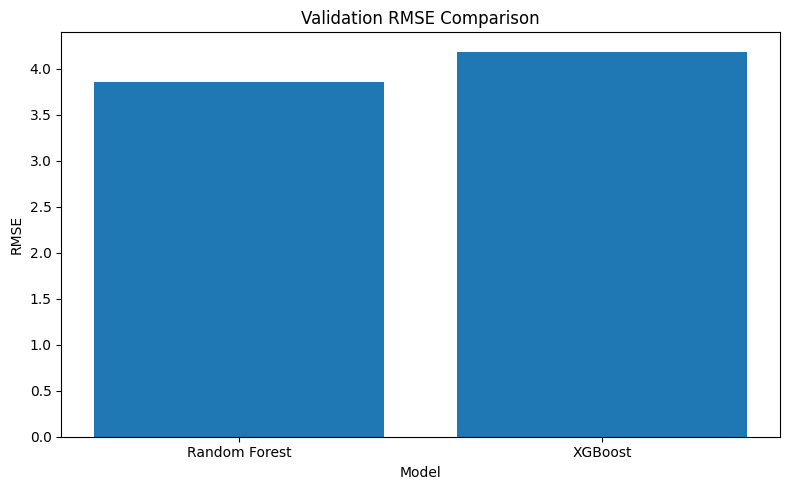

In [24]:
# Model comparison bar chart
plot_model_comparison(results["validation_results"])

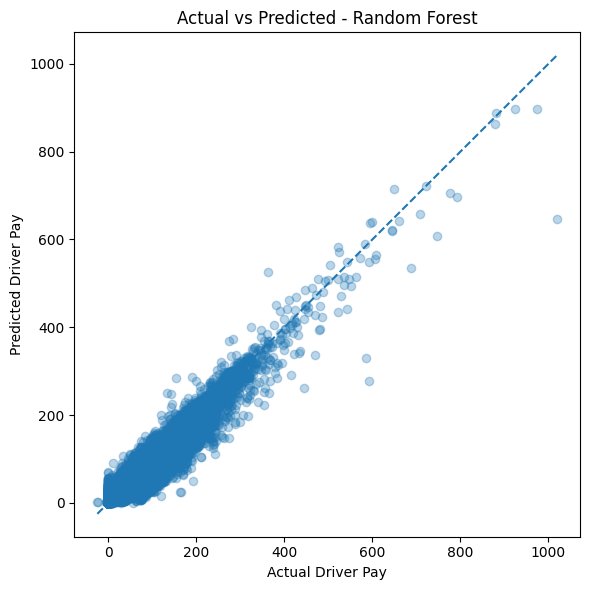

In [25]:
# Actual vs Predicted
plot_actual_vs_predicted(
    results["y_test"],
    results["y_test_pred"],
    model_name=results["best_model_name"]
)

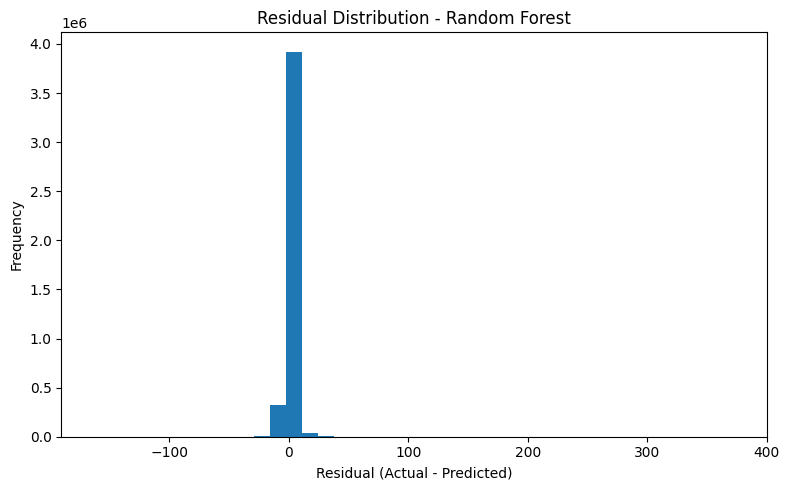

In [26]:
# Residual histogram
plot_residual_histogram(
    results["y_test"],
    results["y_test_pred"],
    model_name=results["best_model_name"]
)

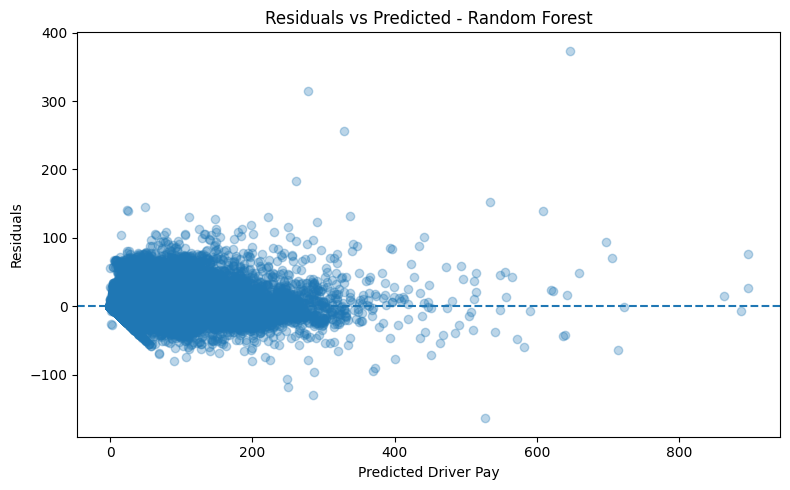

In [27]:
# Residuals vs Predicted
plot_residuals_vs_predicted(
    results["y_test"],
    results["y_test_pred"],
    model_name=results["best_model_name"]
)

### Feature Importance

Feature importance is used to identify which variables contribute most to the model’s predictions.
This provides insight into the relative influence of trip characteristics on driver pay.

Understanding feature importance improves interpretability and helps validate whether the model
aligns with domain expectations.

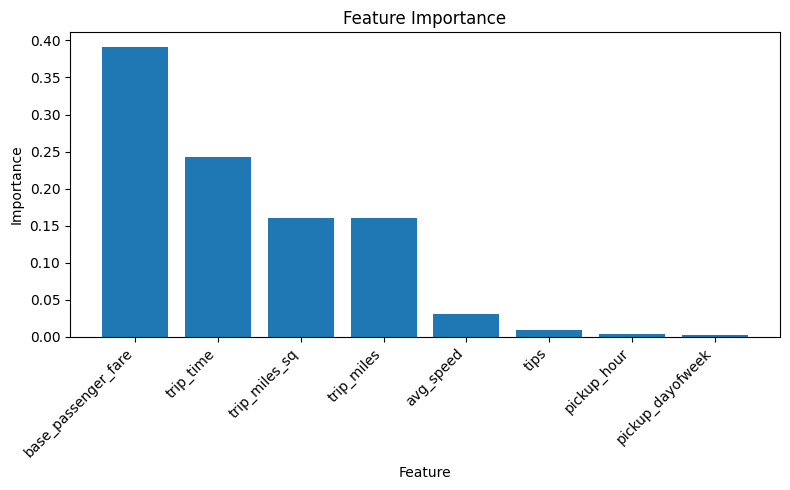

In [32]:
# Feature importance
feature_importance_df = plot_feature_importance(
    results["final_model"],
    FINAL_FEATURES
)

### Partial Dependence Analysis

Partial dependence plots are used to visualize how selected features affect predicted driver pay,
while holding other variables constant.

These plots help interpret the direction and shape of relationships learned by the model,
including potential nonlinear effects.

<Figure size 1000x400 with 0 Axes>

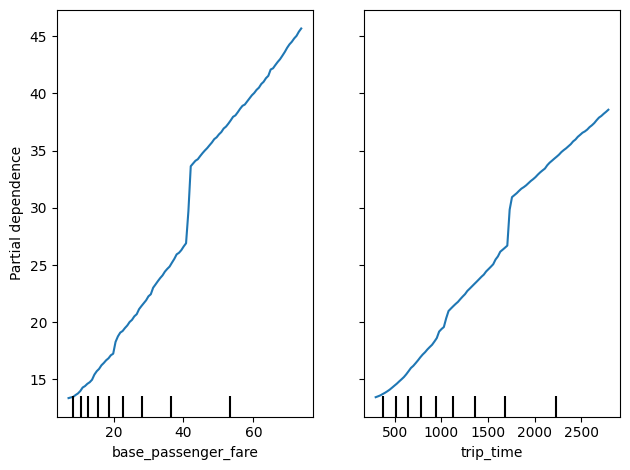

In [33]:
plot_partial_dependence(
    results["final_model"],
    X_test,
    ["base_passenger_fare", "trip_time"]
)

### Robustness Visualization

The following plot shows how test RMSE varies across different split seeds, providing
a visual assessment of model stability.

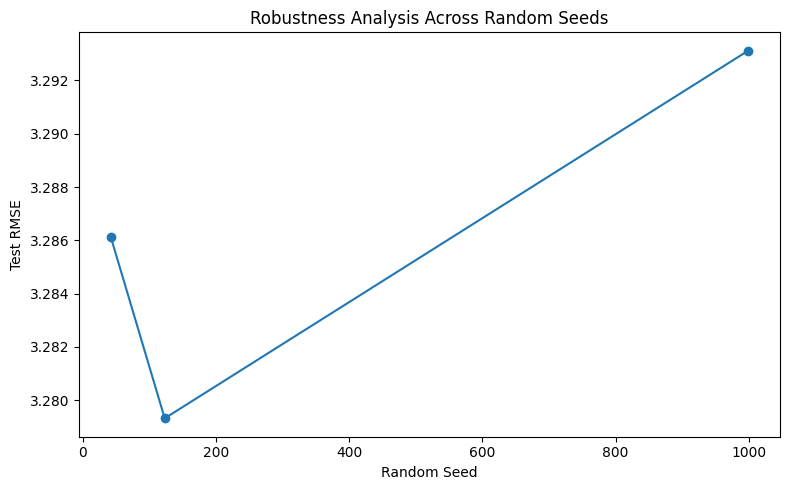

In [50]:
# Robustness plot across seeds
plot_seed_robustness(seed_results)

##**Ensemble stacking**

As an optional extension, a stacking ensemble combining Random Forest and XGBoost with a linear meta-learner was implemented. To control computational cost and memory usage on the large dataset, the ensemble was trained and evaluated on representative sampled subsets. Its performance was then compared against the best single-model baseline.

#1. Imports

In [39]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

#2. Creating the model

In [42]:
STACK_SAMPLE_SIZE = 100000
X, y = prepare_features_target(df, FINAL_FEATURES, TARGET_COL)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X, y, random_state=RANDOM_STATE
)

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)


stack_n = min(STACK_SAMPLE_SIZE, len(X_train_full))
X_stack = X_train_full.sample(n=stack_n, random_state=RANDOM_STATE)
y_stack = y_train_full.loc[X_stack.index]

print("Stacking sample shape:", X_stack.shape)

Stacking sample shape: (100000, 8)


**Defining lighter base models**

In [37]:
rf_stack = build_random_forest(
    random_state=RANDOM_STATE,
    n_estimators=50,
    max_depth=10,
    n_jobs=-1
)

xgb_stack = build_xgboost(
    random_state=RANDOM_STATE,
    n_estimators=80,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

**Building stack model**

In [40]:
stack_model = StackingRegressor(
    estimators=[
        ("rf", rf_stack),
        ("xgb", xgb_stack)
    ],
    final_estimator=LinearRegression(),
    cv=3,
    n_jobs=-1,
    passthrough=False
)

**Fit on Sample**

In [43]:
stack_model.fit(X_stack, y_stack)

StackingRegressor(cv=3,
                  estimators=[('rf',
                               RandomForestRegressor(max_depth=10,
                                                     n_estimators=50, n_jobs=-1,
                                                     random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=80, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                  final_estimator=LinearRegression(), n_jobs=-1)

#3. Evaluate on sample

In [44]:
TEST_SAMPLE_SIZE = 100000
test_n = min(TEST_SAMPLE_SIZE, len(X_test))
X_test_stack = X_test.sample(n=test_n, random_state=RANDOM_STATE)
y_test_stack = y_test.loc[X_test_stack.index]

In [45]:
stack_pred = stack_model.predict(X_test_stack)
stack_metrics = regression_metrics(y_test_stack, stack_pred)
stack_metrics["Model"] = "Stacking Ensemble"

stack_results = pd.DataFrame([stack_metrics])
stack_results.round(4)

,MAE,MSE,RMSE,R2,Model
0,1.6494,12.0302,3.4685,0.9621,Stacking Ensemble


#4. Compare With Best Single Model

In [46]:
best_single_pred = results["final_model"].predict(X_test_stack)
best_single_metrics = regression_metrics(y_test_stack, best_single_pred)
best_single_metrics["Model"] = results["best_model_name"]

bonus_comparison = compare_models(
    [best_single_metrics, stack_metrics],
    sort_by="RMSE"
)

bonus_comparison.round(4)

,MAE,MSE,RMSE,R2,Model
0,1.5952,10.7283,3.2754,0.9662,Random Forest
1,1.6494,12.0302,3.4685,0.9621,Stacking Ensemble
